# 00 — Study Area

Define the Emerald Triangle cultivation footprint.

**Strategy (in order):**
1. Download California DCC licensee CSV → filter to outdoor/mixed-light cultivators in Humboldt, Mendocino, Trinity
2. Load county parcel shapefiles → address-match to get actual parcel polygons for each licensee
3. Supplement with Humboldt County cannabis-specific GIS layer if available
4. Union parcels → study area extent polygon

**Outputs:**
- `data/raw/licensed_parcels.gpkg` — GeoDataFrame of matched cultivation parcels
- `data/raw/study_area.gpkg` — buffered union of all parcels (study extent)
- `data/raw/licensees_unmatched.csv` — rows that failed parcel match (for manual review)

In [1]:
import requests
import zipfile
import re
from pathlib import Path

import pandas as pd
import geopandas as gpd
from shapely.ops import unary_union

RAW = Path('../data/raw')
RAW.mkdir(parents=True, exist_ok=True)

TARGET_COUNTIES   = ['Humboldt', 'Mendocino', 'Trinity']
EMERALD_COUNTIES  = set(TARGET_COUNTIES)

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## 1. Download California DCC licensee data

## 1. Study extent — Census TIGER county boundaries

The DCC withholds cultivator coordinates. Use Census TIGER shapefiles for
the three Emerald Triangle counties as the study extent instead.

Download: https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip
Save to: `data/raw/tl_2023_us_county.zip` (or .shp if already unzipped)

In [2]:
import zipfile

TIGER_ZIP = RAW / 'tl_2023_us_county.zip'
TIGER_SHP = RAW / 'tiger_county'

FIPS_CA = '06'  # California state FIPS
EMERALD_COUNTIES = {'Humboldt', 'Mendocino', 'Trinity'}

if not TIGER_SHP.exists():
    if TIGER_ZIP.exists():
        print('Extracting TIGER zip...')
        with zipfile.ZipFile(TIGER_ZIP) as z:
            z.extractall(TIGER_SHP)
    else:
        # Download directly — this file is ~75 MB
        print('Downloading Census TIGER county shapefile (~75 MB)...')
        r = requests.get(
            'https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip',
            timeout=300, stream=True
        )
        r.raise_for_status()
        TIGER_ZIP.parent.mkdir(parents=True, exist_ok=True)
        with open(TIGER_ZIP, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
        print(f'Downloaded {TIGER_ZIP.stat().st_size / 1e6:.1f} MB')
        with zipfile.ZipFile(TIGER_ZIP) as z:
            z.extractall(TIGER_SHP)

shp_hits = list(TIGER_SHP.glob('*.shp'))
counties_us = gpd.read_file(shp_hits[0])
print(f'Loaded {len(counties_us):,} US counties')
counties_us.columns.tolist()

Downloaded 83.5 MB
Loaded 3,235 US counties


['STATEFP',
 'COUNTYFP',
 'COUNTYNS',
 'GEOID',
 'GEOIDFQ',
 'NAME',
 'NAMELSAD',
 'LSAD',
 'CLASSFP',
 'MTFCC',
 'CSAFP',
 'CBSAFP',
 'METDIVFP',
 'FUNCSTAT',
 'ALAND',
 'AWATER',
 'INTPTLAT',
 'INTPTLON',
 'geometry']

     NAME         NAMELSAD GEOID
  Trinity   Trinity County 06105
Mendocino Mendocino County 06045
 Humboldt  Humboldt County 06023


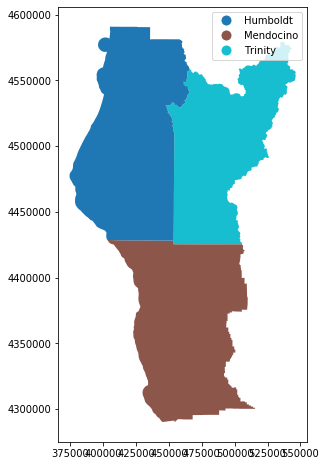

In [3]:
# Filter to Emerald Triangle counties (CA FIPS = 06)
emerald = counties_us[
    (counties_us['STATEFP'] == FIPS_CA) &
    (counties_us['NAME'].isin(EMERALD_COUNTIES))
].to_crs('EPSG:32610').copy()

print(emerald[['NAME', 'NAMELSAD', 'GEOID']].to_string(index=False))
emerald.plot(column='NAME', legend=True, figsize=(8, 8))

## 2. Humboldt County cannabis permit GIS layer

Humboldt County publishes cannabis cultivation permit polygons separately from the state.
This is the primary source of labeled cultivation cells.

- Portal: https://humboldtgov.org/1475/GIS-Downloads
- Direct REST: https://services2.arcgis.com/YpuAFMHGBmNKSHAY/arcgis/rest/services
- Look for a layer named `Cannabis`, `CannabisPermits`, or `Cultivation`

Save any downloaded file to: `data/raw/humboldt_cannabis.*`

In [4]:
# Try loading Humboldt cannabis permit layer
humboldt_hits = list(RAW.glob('humboldt_cannabis.*'))

if humboldt_hits:
    hc = gpd.read_file(humboldt_hits[0]).to_crs('EPSG:32610')
    print(f"Humboldt cannabis layer: {len(hc):,} features")
    print(hc.columns.tolist())
    hc.head(3)
else:
    print("Humboldt cannabis GIS layer not found.")
    print("Proceeding with county boundary only — all cells treated as 'background'.")
    print("Label cells later once Humboldt data is obtained.")
    hc = None

Humboldt cannabis GIS layer not found.
Proceeding with county boundary only — all cells treated as 'background'.
Label cells later once Humboldt data is obtained.


## 3. Build study area and labeled polygon layer

In [5]:
from shapely.ops import unary_union

# Study extent = union of three county polygons + 2 km buffer
study_area = gpd.GeoDataFrame(
    geometry=[unary_union(emerald.geometry).buffer(2_000)],
    crs='EPSG:32610',
)

# Labeled cultivation polygons (if Humboldt data available)
if hc is not None:
    cultivation_polys = hc.copy()
    cultivation_polys['label'] = 'cultivation'
    cultivation_polys['source'] = 'Humboldt County GIS'
else:
    # Placeholder: empty layer with correct schema
    cultivation_polys = gpd.GeoDataFrame(
        columns=['label', 'source', 'geometry'],
        geometry='geometry', crs='EPSG:32610'
    )

print(f"Study area: {study_area.total_bounds}")
print(f"Cultivation polygons: {len(cultivation_polys):,}")

Study area: [ 372310.71942094 4288115.08977664  548526.34165752 4592940.61954497]
Cultivation polygons: 0


## 4. Quick map

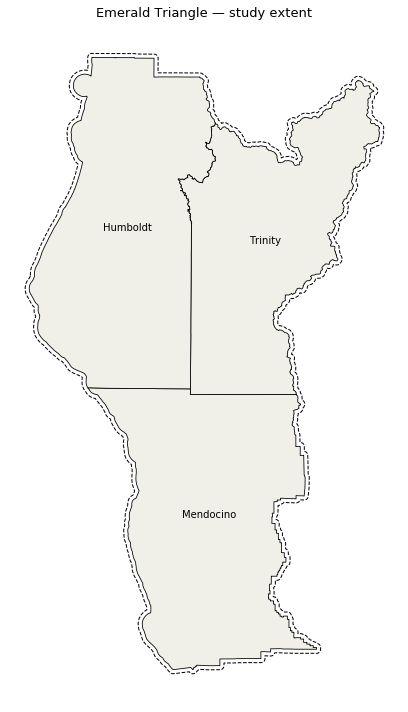

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 10))
emerald.plot(ax=ax, color='#f0f0e8', edgecolor='k', linewidth=0.8)
study_area.boundary.plot(ax=ax, color='black', linewidth=1, linestyle='--')
if len(cultivation_polys):
    cultivation_polys.plot(ax=ax, color='green', alpha=0.5, label='Permitted cultivation')
for _, row in emerald.iterrows():
    c = row.geometry.centroid
    ax.annotate(row['NAME'], (c.x, c.y), ha='center', fontsize=10)
ax.set_title('Emerald Triangle — study extent', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../img/00_study_area.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Save outputs

In [8]:
emerald.to_file(RAW / 'emerald_counties.gpkg', driver='GPKG')
study_area.to_file(RAW / 'study_area.gpkg', driver='GPKG')
if len(cultivation_polys):
    cultivation_polys.to_file(RAW / 'cultivation_polygons.gpkg', driver='GPKG')

print("Saved:")
print("  data/raw/emerald_counties.gpkg")
print("  data/raw/study_area.gpkg")
if len(cultivation_polys):
    print("  data/raw/cultivation_polygons.gpkg")
print(f"\nCRS: EPSG:32610 (UTM Zone 10N)")
print(f"Counties: {emerald['NAME'].tolist()}")
print(f"Study area bounds: {study_area.total_bounds.round(0)}")

Saved:
  data/raw/emerald_counties.gpkg
  data/raw/study_area.gpkg

CRS: EPSG:32610 (UTM Zone 10N)
Counties: ['Trinity', 'Mendocino', 'Humboldt']
Study area bounds: [ 372311. 4288115.  548526. 4592941.]
